## 1. Carga de Datos

Importamos la biblioteca pandas y cargamos el archivo CSV que contiene los datos de temperatura.

In [15]:
import pandas as pd
datos = pd.read_csv("celsius.csv")

## 2. Exploración de Datos

Verificamos la estructura y el tipo de datos del DataFrame para asegurarnos de que están correctamente formateados.

In [16]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   celsius     7 non-null      int64  
 1   fahrenheit  7 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 240.0 bytes


## 3. Visualización de Datos

Visualizamos los primeros registros del dataset para familiarizarnos con los datos.

In [17]:
datos.head()

,celsius,fahrenheit
0,-40,-40.0
1,-10,14.0
2,0,32.0
3,8,46.4
4,15,59.0


## 4. Gráfico de Dispersión

Creamos un gráfico de dispersión utilizando seaborn para visualizar la relación entre Celsius y Fahrenheit.
- **X**: Grados Celsius
- **Y**: Grados Fahrenheit
- **Colores**: Escala de colores coolwarm que representa los valores de Fahrenheit

<Axes: xlabel='celsius', ylabel='fahrenheit'>

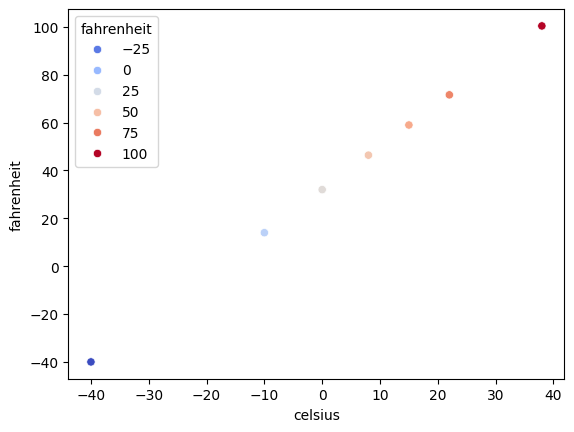

In [18]:
import seaborn as sb
sb.scatterplot(x="celsius", y="fahrenheit", data=datos,
hue = "fahrenheit", palette="coolwarm")

## 5. Separación de Características y Etiquetas

Definimos:
- **X (características)**: Variable independiente (grados Celsius)
- **y (etiqueta)**: Variable dependiente (grados Fahrenheit)

In [19]:
#caracteristicas (X), etiqueta (y)
x = datos["celsius"]
y = datos["fahrenheit"]

## 6. Visualización de Etiquetas

Mostramos los valores de la variable objetivo (Fahrenheit) para verificar su estructura.

In [20]:
y

0    -40.0
1     14.0
2     32.0
3     46.4
4     59.0
5     71.6
6    100.4
Name: fahrenheit, dtype: float64

## 7. Preparación de Datos para el Modelo

Transformamos los datos al formato requerido por scikit-learn:
- **X**: Convertido a matriz de una columna con reshape(-1, 1)
- **y**: Convertido a matriz de una columna con reshape(-1, 1)

In [21]:
#X.values
#[-40, -10, 0, 8, ...]
#[[-40], [-10], [0], [8], ..]
x_procesada = x.values.reshape(-1, 1)
y_procesada = y.values.reshape(-1, 1)

## 8. Creación del Modelo

Instanciamos un modelo de regresión lineal de scikit-learn.
**Fórmula de regresión lineal**: y = m·x + b
- **m**: Pendiente (coeficiente)
- **b**: Intercepto

In [22]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()


## 9. Entrenamiento del Modelo

Entrenamos el modelo con los datos de Celsius y Fahrenheit.
El algoritmo encuentra la línea de mejor ajuste que minimiza el error cuadrático medio.

In [23]:
#entrenameninto
modelo.fit(x_procesada, y_procesada)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 10. Predicción

Probamos el modelo con un nuevo valor: 7900 grados Celsius.
El modelo aplica la fórmula aprendida para predecir el equivalente en Fahrenheit.

In [24]:
celsius= 7900
prediccion = modelo.predict([[celsius]])
print(f"{celsius} grados celsius son {prediccion} grados fahrenheit")

7900 grados celsius son [[14252.]] grados fahrenheit


## 11. Evaluación del Modelo

Calculamos el coeficiente de determinación (R²) que indica qué tan bien se ajusta el modelo a los datos.
- **R² = 1.0**: Ajuste perfecto (no hay error en las predicciones)
- Esto ocurre porque la conversión Celsius ↔ Fahrenheit es una relación perfectamente lineal.

In [25]:
modelo.score(x_procesada, y_procesada)

1.0